<a href="https://colab.research.google.com/github/A-Vineela/IIIT-H-Projects-and-Labs/blob/main/Module-4/Lab-3/Test_Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 2. Testing on Diabetes dataset and checking performance of each variant

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
# Load Diabetes dataset
diabetes=load_diabetes()
X=diabetes.data
y=diabetes.target.reshape(-1,1)

# Standardize features
scaler=StandardScaler()
X=scaler.fit_transform(X)
# Add bias term
X_b=np.c_[np.ones((X.shape[0],1)),X]

In [3]:
def cal_cost(theta,X,y):
    m=len(y)
    predictions=X.dot(theta)
    cost=(1/(2*m))*np.sum((predictions-y)**2)
    return cost

In [4]:
def gradient_descent(X,y,theta,learning_rate=0.01,iterations=200):
    m=len(y)
    cost_history=np.zeros(iterations)
    for it in range(iterations):
        predictions=X.dot(theta)
        theta=theta-(learning_rate/m)*(X.T.dot(predictions-y))
        cost_history[it]=cal_cost(theta,X,y)
    return theta , cost_history

In [5]:
def stochastic_gradient_descent(X,y,theta,learning_rate=0.01,iterations=200):
    m=len(y)
    cost_history=np.zeros(iterations)
    for it in range(iterations):
        cost=0
        for i in range(m):
            rand_ind=np.random.randint(m)
            X_i=X[rand_ind:rand_ind+1]
            y_i=y[rand_ind:rand_ind+1]
            prediction=X_i.dot(theta)
            theta=theta-learning_rate*X_i.T.dot(prediction-y_i)
            cost+=cal_cost(theta,X_i,y_i)
        cost_history[it] =cost
    return theta , cost_history

In [6]:
def minibatch_gradient_descent(X, y, theta,learning_rate=0.01,iterations=200,batch_size=32):
    m =len(y)
    cost_history=np.zeros(iterations)
    for it in range(iterations):
        indices=np.random.permutation(m)
        X_shuffled=X[indices]
        y_shuffled=y[indices]
        cost=0
        for i in range(0,m,batch_size):
            X_batch=X_shuffled[i:i+batch_size]
            y_batch=y_shuffled[i:i+batch_size]
            prediction=X_batch.dot(theta)
            theta=theta-learning_rate*(1/len(X_batch))*\
            X_batch.T.dot(prediction-y_batch)
            cost+=cal_cost(theta,X_batch,y_batch)
        cost_history[it]=cost
    return theta , cost_history

In [7]:
n_features=X_b.shape[1]
# Batch GD
theta_batch=np.random.randn(n_features,1)
theta_batch,batch_cost=gradient_descent(
    X_b,y,theta_batch,
    learning_rate=0.01,
    iterations=200
)
# SGD
theta_sgd= np.random.randn(n_features,1)
theta_sgd,sgd_cost=stochastic_gradient_descent(
    X_b, y, theta_sgd,
    learning_rate=0.0001,
    iterations=200
)
# Mini-Batch GD
theta_mini=np.random.randn(n_features, 1)
theta_mini,mini_cost=minibatch_gradient_descent(
    X_b, y, theta_mini,
    learning_rate=0.01,
    iterations=200,
    batch_size=32
)

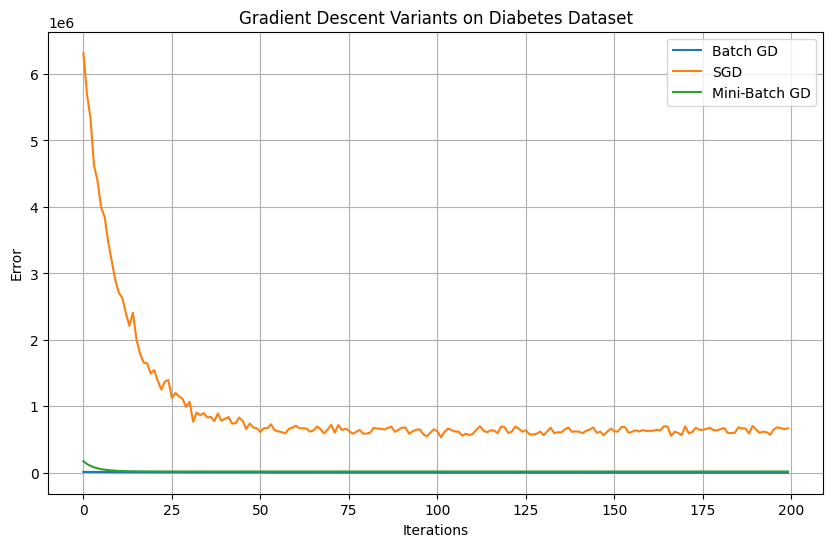

In [8]:
plt.figure(figsize=(10,6))
plt.plot(batch_cost, label='Batch GD')
plt.plot(sgd_cost, label='SGD')
plt.plot(mini_cost, label='Mini-Batch GD')
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.title("Gradient Descent Variants on Diabetes Dataset")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
print("Batch GD Final Error:",batch_cost[-1])
print("SGD Final Error:",sgd_cost[-1])
print("Mini-Batch GD Final Error:",mini_cost[-1])

Batch GD Final Error: 1659.5844862498598
SGD Final Error: 670315.9624428111
Mini-Batch GD Final Error: 20118.35266663207


2. Observation

- Batch Gradient Descent achieved the lowest final error(1659.58) and showed smooth , stable convergence.
- Stochastic Gradient Descent(SGD) had the highest error(670315.96) and exhibited significant fluctuations due to random updates.
- Mini Batch Gradient Descent converged faster than Batch GD initially but settled at a higher error(20118.35).

Conclusion : On the Diabetes dataset , Batch Gradient Descent performed best in terms of accuracy , while Mini Batch GD provided a reasonable trade off between speed and performance. SGD was the least stable and least accurate with the chosen learning rate and number of iterations.